In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
path_orders = "/content/drive/MyDrive/Colab Notebooks/Porto - Restaurant Pizza Sales/orders.csv"
path_order_details = "/content/drive/MyDrive/Colab Notebooks/Porto - Restaurant Pizza Sales/order_details.csv"
path_pizzas = "/content/drive/MyDrive/Colab Notebooks/Porto - Restaurant Pizza Sales/pizzas.csv"
path_pizza_types = "/content/drive/MyDrive/Colab Notebooks/Porto - Restaurant Pizza Sales/pizza_types.csv"

In [13]:
orders = pd.read_csv(path_orders)
order_details = pd.read_csv(path_order_details)
pizzas = pd.read_csv(path_pizzas)
pizza_types = pd.read_csv(path_pizza_types, encoding='latin-1')

In [15]:
print("Data Orders:")
display(orders.head)

Data Orders:


<bound method NDFrame.head of        order_id        date      time
0             1  2015-01-01  11:38:36
1             2  2015-01-01  11:57:40
2             3  2015-01-01  12:12:28
3             4  2015-01-01  12:16:31
4             5  2015-01-01  12:21:30
...         ...         ...       ...
21345     21346  2015-12-31  20:51:07
21346     21347  2015-12-31  21:14:37
21347     21348  2015-12-31  21:23:10
21348     21349  2015-12-31  22:09:54
21349     21350  2015-12-31  23:02:05

[21350 rows x 3 columns]>

In [16]:
# Mengabungkan order_details dengan pizzas (untuk dapat harga)
df_master = pd.merge(order_details, pizzas, on='pizza_id', how='left')

# Menggabungkan pizza_types (untuk dapat nama & kategori pizza)
df_master = pd.merge(df_master, pizza_types, on='pizza_type_id', how='left')

# Menggabungkan dengan orders (untuk dapat data tanggal & jam)
df_master = pd.merge(df_master, orders, on='order_id', how='left')

# Menghitung Total Pendapatan per baris (Quantity x Price)
df_master['revenue'] = df_master['quantity'] * df_master['price']

# Mengubah kolom date dan time ke format datetime agar mudah diolah
df_master['date'] = pd.to_datetime(df_master['date'])
df_master['time'] = pd.to_datetime(df_master['time'], format='%H:%M:%S').dt.time
print("Data berhasil digabungkan! Total baris:", len(df_master))

Data berhasil digabungkan! Total baris: 48620


# Menghitung Ringkasan Eksekutif (KPIs)

In [24]:
total_revenue = df_master['revenue'].sum()
total_orders = df_master['order_id'].nunique()
total_pizzas_sold = df_master['quantity'].sum()
aov = total_revenue / total_orders

print(f"Total Pendapatan : ${total_revenue:,.2f}")
print(f"Total Transaksi  : {total_orders:,} pesanan")
print(f"Total Pizza Terjual: {total_pizzas_sold:,} loyang")
print(f"Average Order Value (AOV): ${aov:,.2f}")

Total Pendapatan : $817,860.05
Total Transaksi  : 21,350 pesanan
Total Pizza Terjual: 49,574 loyang
Average Order Value (AOV): $38.31


# Top 5 Pizza Paling Laris (Berdasarkan Kuantitas)

In [25]:
top_pizzas = df_master.groupby('name')['quantity'].sum().sort_values(ascending=False).head(5)
print("--- TOP 5 PIZZA PALING LARIS ---")
print(top_pizzas)

--- TOP 5 PIZZA PALING LARIS ---
name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64


# Visualisasi Data (Charting)

/tmp/ipykernel_2793/1855259079.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_orders, x='hour', y='order_id', palette='Blues_r')


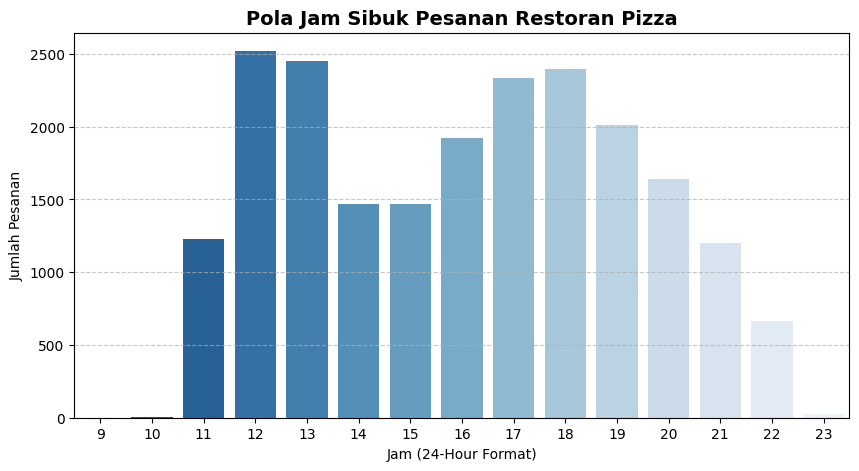

In [26]:
# Ekstrak komponen jam dari data orders
orders['hour'] = pd.to_datetime(orders['time'], format='%H:%M:%S').dt.hour

# Hitung jumlah order per jam
hourly_orders = orders.groupby('hour')['order_id'].count().reset_index()

# Membuat Grafik
plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_orders, x='hour', y='order_id', palette='Blues_r')
plt.title('Pola Jam Sibuk Pesanan Restoran Pizza', fontsize=14, fontweight='bold')
plt.xlabel('Jam (24-Hour Format)')
plt.ylabel('Jumlah Pesanan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [27]:
df_master.to_csv('pizza_sales_clean_master.csv', index=False)